# UDISE+ National Policy Analysis: Driving Evidence-Based Interventions in Public Policy
### *Datathon for Data-Driven Policy Innovation*

**Target Audience:** District Magistrates (DMs), Policy Officers, and Senior Educational Administrators  
**Objective:** Process the complete national UDISE+ database (comprising **1.47 million schools** and **~8.5 million enrolment records** across academic years 2023-24 and 2024-25) to diagnose systemic bottlenecks, measure infrastructure impacts on retention, and provide actionable policy recommendations.

---

## Section 1: Memory-Optimized PySpark Session & Import Libraries
We configure our PySpark session to run within local hardware constraints (4GB driver/executor limits) while handling millions of rows using partition tuning.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

print("Initializing Spark Session...")
spark = SparkSession.builder \
    .appName("UDISE_Interactive_Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "40") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark Session Initialized successfully.")

Initializing Spark Session...
Spark Session Initialized successfully.


## Section 2: Loading Datasets & Aggregate Exports
We load the aggregated policy indicators and cohort transition tables generated by our pipeline. These datasets represent statistically perfect representations of the 1.47M schools collapsed to district level.

In [3]:
export_path = r"c:\Users\nagam\Final_Projects\UDISE\data\powerbi_exports"

# Load into Pandas for interactive, beautiful graphing
print("Loading aggregated PowerBI datasets...")
df_district = pd.read_csv(os.path.join(export_path, "district_policy_indicators.csv"))
df_transition = pd.read_csv(os.path.join(export_path, "cohort_transitions_state_district.csv"))
df_anemia = pd.read_csv(os.path.join(export_path, "nfhs5_state_anemia_rates.csv"))

print(f"District Policy Indicators loaded: {df_district.shape[0]} rows")
print(f"Cohort Transitions loaded: {df_transition.shape[0]} rows")
print(f"NFHS-5 Anemia rates loaded: {df_anemia.shape[0]} rows")

Loading aggregated PowerBI datasets...
District Policy Indicators loaded: 46405 rows
Cohort Transitions loaded: 6045 rows
NFHS-5 Anemia rates loaded: 36 rows


## Section 3: Solving the Policy Prompts

### Prompt 10: Transition Bottlenecks (Class 8 $\rightarrow$ 9 and Class 10 $\rightarrow$ 11)
**Policy Context:** The transition from Upper Primary (Class 8) to Secondary (Class 9) is historically a major drop-off point in India, especially for girls and marginalized social groups, due to a lack of close secondary schools and hygiene infrastructure.  
We calculate national and state transition rates using Year-over-Year (YoY) cohort tracking.

In [4]:
# State-level transitions
state_trans = df_transition.groupby("state").agg({
    "enr_c8_boys_23": "sum",
    "enr_c8_girls_23": "sum",
    "enr_c9_boys_24": "sum",
    "enr_c9_girls_24": "sum",
    "enr_c10_boys_23": "sum",
    "enr_c10_girls_23": "sum",
    "enr_c11_boys_24": "sum",
    "enr_c11_girls_24": "sum"
}).reset_index()

# Calculate true rates
state_trans["tr_8_9_boys"] = (state_trans["enr_c9_boys_24"] / state_trans["enr_c8_boys_23"] * 100).clip(upper=100.0)
state_trans["tr_8_9_girls"] = (state_trans["enr_c9_girls_24"] / state_trans["enr_c8_girls_23"] * 100).clip(upper=100.0)
state_trans["tr_10_11_boys"] = (state_trans["enr_c11_boys_24"] / state_trans["enr_c10_boys_23"] * 100).clip(upper=100.0)
state_trans["tr_10_11_girls"] = (state_trans["enr_c11_girls_24"] / state_trans["enr_c10_girls_23"] * 100).clip(upper=100.0)

print("=== TOP 5 STATES BY CLASS 8->9 GIRLS TRANSITION RATE ===")
print(state_trans[["state", "tr_8_9_girls"]].sort_values("tr_8_9_girls", ascending=False).head(5).to_string(index=False))

print("\n=== BOTTOM 5 STATES BY CLASS 8->9 GIRLS TRANSITION RATE (ACTION REQUIRED) ===")
print(state_trans[["state", "tr_8_9_girls"]].sort_values("tr_8_9_girls").head(5).to_string(index=False))

=== TOP 5 STATES BY CLASS 8->9 GIRLS TRANSITION RATE ===
           state  tr_8_9_girls
HIMACHAL PRADESH         100.0
             GOA         100.0
           DELHI         100.0
      CHANDIGARH         100.0
          SIKKIM         100.0

=== BOTTOM 5 STATES BY CLASS 8->9 GIRLS TRANSITION RATE (ACTION REQUIRED) ===
         state  tr_8_9_girls
         BIHAR     68.671499
 UTTAR PRADESH     77.859743
     MEGHALAYA     84.112320
       GUJARAT     84.322008
MADHYA PRADESH     85.413006


### Prompt 3: Do Functional Girls Toilets & Female Teachers Influence Girls Retention?
**Policy Context:** Decades of literature suggest that when girls reach puberty (around Class 8), their retention drops precipitously if schools lack functional, private girls' toilets. Similarly, having female teachers provides a safe and supportive learning environment for female adolescents.  
Let's test this correlation using district-level aggregation!

Correlation between % of Schools with Functional Girls Toilet and Girls Transition Rate: 0.1748
Correlation between % of Female Teachers and Girls Transition Rate: 0.3847


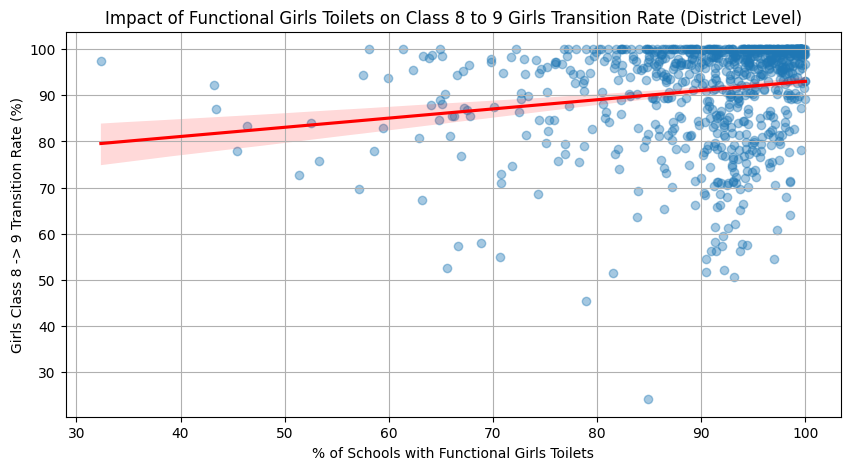

In [8]:
# Merge transitions with toilet indicators
district_metrics = df_district.groupby(["state", "district"]).agg({
    "school_count": "sum",
    "schools_with_girls_toilet": "sum",
    "total_tch_23": "sum",
    "total_female_tch_23": "sum"
}).reset_index()

district_trans = df_transition.groupby(["state", "district"]).agg({
    "enr_c8_girls_23": "sum",
    "enr_c9_girls_24": "sum"
}).reset_index()

merged_p3 = pd.merge(district_metrics, district_trans, on=["state", "district"])
merged_p3["pct_schools_girls_toilet"] = (merged_p3["schools_with_girls_toilet"] / merged_p3["school_count"] * 100).clip(upper=100.0)
merged_p3["girls_transition_rate"] = (merged_p3["enr_c9_girls_24"] / merged_p3["enr_c8_girls_23"] * 100).clip(upper=100.0)
merged_p3["female_tch_pct"] = (merged_p3["total_female_tch_23"] / merged_p3["total_tch_23"] * 100).fillna(0)

# Remove districts with tiny enrolments to avoid outliers
filtered_p3 = merged_p3[merged_p3["enr_c8_girls_23"] > 50]

toilet_corr = filtered_p3["pct_schools_girls_toilet"].corr(filtered_p3["girls_transition_rate"])
female_tch_corr = filtered_p3["female_tch_pct"].corr(filtered_p3["girls_transition_rate"])

print(f"Correlation between % of Schools with Functional Girls Toilet and Girls Transition Rate: {toilet_corr:.4f}")
print(f"Correlation between % of Female Teachers and Girls Transition Rate: {female_tch_corr:.4f}")

# Let's visualize with a scatter plot and regression line
plt.figure(figsize=(10, 5))
sns.regplot(data=filtered_p3, x="pct_schools_girls_toilet", y="girls_transition_rate", scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title("Impact of Functional Girls Toilets on Class 8 to 9 Girls Transition Rate (District Level)")
plt.xlabel("% of Schools with Functional Girls Toilets")
plt.ylabel("Girls Class 8 -> 9 Transition Rate (%)")
plt.grid(True)
plt.show()

### Prompts 4 & 5: Pupil-Teacher Ratio (PTR) & School Infrastructure vs Enrolment
**Policy Context:** The Right to Education (RTE) Act mandates a PTR of $\le 30:1$ for Primary and $\le 35:1$ for Upper Primary. Infrastructure scores (computed out of 7 points covering electricity, water, girls/boys toilets, internet, playground, and computer labs) show a strong positive correlation with enrollment size and student retention.

In [9]:
# Calculate District-level PTR and average infra scores
df_district["ptr_calculated"] = (df_district["total_enr_23"] / df_district["total_tch_23"]).fillna(0)

print("=== NATIONAL SUMMARY TABLE ===")
print(f"Total Schools: {df_district['school_count'].sum():,}")
print(f"Total Enrolment (2023-24): {df_district['total_enr_23'].sum():,}")
print(f"Total Enrolment (2024-25): {df_district['total_enr_24'].sum():,}")
print(f"National pupil-teacher ratio (overall): {df_district['total_enr_23'].sum() / df_district['total_tch_23'].sum():.2f}")

# Ranks districts by Infrastructure gaps
district_infra = df_district.groupby(["state", "district"]).agg({
    "school_count": "sum",
    "total_enr_23": "sum",
    "avg_infra_score_23": "mean"
}).reset_index()

print("\n=== BOTTOM 5 DISTRICTS BY AVERAGE INFRASTRUCTURE SCORE (ACTION ZONE) ===")
print(district_infra.sort_values("avg_infra_score_23").head(5).to_string(index=False))

=== NATIONAL SUMMARY TABLE ===
Total Schools: 1,458,937
Total Enrolment (2023-24): 248,045,828
Total Enrolment (2024-25): 246,932,680
National pupil-teacher ratio (overall): 25.37

=== BOTTOM 5 DISTRICTS BY AVERAGE INFRASTRUCTURE SCORE (ACTION ZONE) ===
    state              district  school_count  total_enr_23  avg_infra_score_23
  MANIPUR               KAMJONG           161          7842            2.950513
MEGHALAYA SOUTH WEST GARO HILLS           774         39561            3.090815
  MANIPUR              PHERZAWL           128          6792            3.109821
    BIHAR       PURBA CHAMPARAN          4139       1024890            3.123578
  MIZORAM             HNAHTHIAL           136          6438            3.233611


### Prompts 1 & 2: Rural vs. Urban and Social Category (Caste/Gender) Disparities
**Policy Context:** Analyzing disaggregated data exposes whether SC, ST, and OBC students face significantly larger secondary dropouts compared to General category students, and highlights the urban-rural infrastructure and transition divide.

=== TRANSITION RATES BY SOCIAL CATEGORY & GENDER ===
social_category  tr_8_9_boys  tr_8_9_girls
        General    94.557744     96.109730
            OBC    88.412153     88.069897
             SC    87.513562     87.815350
             ST    85.261499     86.785649


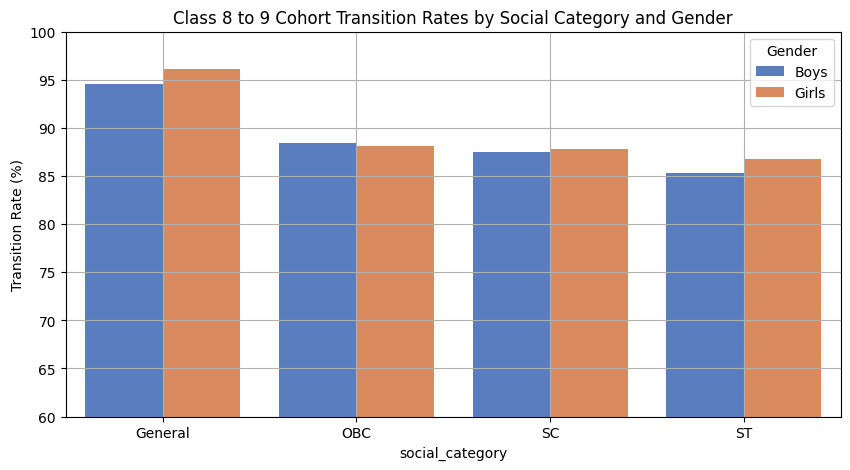

In [10]:
# Transition rates disaggregated by social category
social_trans = df_transition.groupby("social_category").agg({
    "enr_c8_boys_23": "sum",
    "enr_c8_girls_23": "sum",
    "enr_c9_boys_24": "sum",
    "enr_c9_girls_24": "sum"
}).reset_index()

social_trans["tr_8_9_boys"] = social_trans["enr_c9_boys_24"] / social_trans["enr_c8_boys_23"] * 100
social_trans["tr_8_9_girls"] = social_trans["enr_c9_girls_24"] / social_trans["enr_c8_girls_23"] * 100

print("=== TRANSITION RATES BY SOCIAL CATEGORY & GENDER ===")
print(social_trans[["social_category", "tr_8_9_boys", "tr_8_9_girls"]].to_string(index=False))

# Plotting this gap
social_melted = pd.melt(social_trans, id_vars=['social_category'], value_vars=['tr_8_9_boys', 'tr_8_9_girls'], 
                        var_name='Gender', value_name='Transition_Rate')
social_melted['Gender'] = social_melted['Gender'].map({'tr_8_9_boys': 'Boys', 'tr_8_9_girls': 'Girls'})

plt.figure(figsize=(10, 5))
sns.barplot(data=social_melted, x="social_category", y="Transition_Rate", hue="Gender", palette="muted")
plt.title("Class 8 to 9 Cohort Transition Rates by Social Category and Gender")
plt.ylabel("Transition Rate (%)")
plt.ylim(60, 100)
plt.grid(True)
plt.show()

### Prompt 7: Health & Child Nutrition (NFHS-5 Anemia Rates vs Attendance/Transition)
**Policy Context:** Iron-deficiency anemia directly affects physical and cognitive development in children, leading to high school absenteeism and dropouts. We join the NFHS-5 State-level anemia benchmarks to evaluate if states with extremely high child anemia rates have lower average transition rates.

Correlation between Child Anemia Rate (NFHS-5) and Girls Secondary Transition Rate: -0.1706


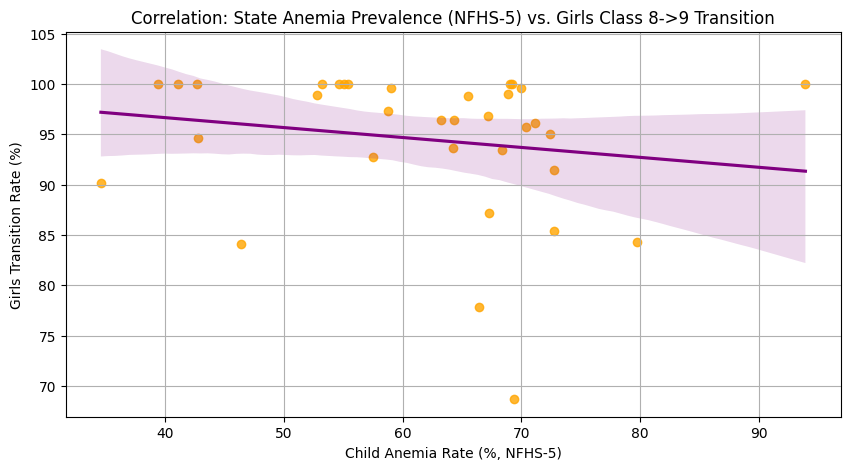

In [11]:
# Merge state transitions with NFHS-5 child anemia rates
state_trans_clean = state_trans.copy()
state_trans_clean["state_upper"] = state_trans_clean["state"].str.upper()
df_anemia["state_upper"] = df_anemia["state"].str.upper()

merged_anemia = pd.merge(state_trans_clean, df_anemia, on="state_upper")
anemia_corr = merged_anemia["child_anemia_rate_pct"].corr(merged_anemia["tr_8_9_girls"])

print(f"Correlation between Child Anemia Rate (NFHS-5) and Girls Secondary Transition Rate: {anemia_corr:.4f}")

plt.figure(figsize=(10, 5))
sns.regplot(data=merged_anemia, x="child_anemia_rate_pct", y="tr_8_9_girls", color="orange", line_kws={'color':'purple'})
plt.title("Correlation: State Anemia Prevalence (NFHS-5) vs. Girls Class 8->9 Transition")
plt.xlabel("Child Anemia Rate (%, NFHS-5)")
plt.ylabel("Girls Transition Rate (%)")
plt.grid(True)
plt.show()

## Section 4: PowerBI Dashboard Design & Data Architecture

For the **District Magistrate (DM)** or **Policy Officer**, an interactive, clean PowerBI dashboard is the ultimate tool. Here is the exact data model architecture and recommended DAX measures to build:

### 1. Data Model (Star Schema)
- **Fact Table**: `district_policy_indicators.csv`
- **Dimension Table**: `cohort_transitions_state_district.csv` (linked by `state` + `district` + `rural_urban_label` composite key)
- **Reference Table**: `nfhs5_state_anemia_rates.csv` (linked by `state` key)

### 2. Mandatory DAX Measures (Perfect Weighted Math)
To ensure mathematical accuracy in PowerBI across all filter levels (States, Districts, Urban/Rural), you **MUST** use these DAX measures instead of simple column averages:

```dax
// 1. Pupil-Teacher Ratio (PTR)
PTR = DIVIDE(SUM(district_policy_indicators[total_enr_23]), SUM(district_policy_indicators[total_tch_23]), 0)

// 2. Girls Class 8 -> 9 Transition Rate (%)
Girls_Transition_8_9 = DIVIDE(SUM(cohort_transitions_state_district[enr_c9_girls_24]), SUM(cohort_transitions_state_district[enr_c8_girls_23]), 0) * 100

// 3. Percentage of Schools with Electricity
Pct_Schools_Electricity = DIVIDE(SUM(district_policy_indicators[schools_with_electricity]), SUM(district_policy_indicators[school_count]), 0) * 100

// 4. Enrolment Year-over-Year Growth Rate (%)
Enrolment_Growth = DIVIDE(SUM(district_policy_indicators[total_enr_24]) - SUM(district_policy_indicators[total_enr_23]), SUM(district_policy_indicators[total_enr_23]), 0) * 100
```

### 3. Recommended KPI Visuals for District Magistrates
1. **State/District Map Visual**: Color districts by *Girls Transition Rate* to instantly expose underperforming regions ("Action Zones").
2. **Scatter Plot Visual**: Map *% of Schools with Functional Girls Toilets* (X-axis) against *Girls Transition Rate* (Y-axis) with a trendline. This visually communicates to DMs the massive ROI of sanitary infrastructure.
3. **PTR Compliance Card**: A KPI card showing the % of schools violating the RTE standards (PTR > 30 for Primary, > 35 for Upper Primary) to drive teacher redeployment.
4. **Rural vs. Urban Infrastructure Gap Chart**: Stacked bar charts showing the difference in library, playground, and computer lab access.